# Mini-TP 5 — Federa tu modelo y mide el trade-off (starter)

**Operaciones de Aprendizaje Automático II · CEIA – FIUBA · Entrega individual, esta semana**

Corre una **simulación federada** con FedAvg y **analiza el trade-off privacidad vs performance**. Las celdas de la actividad fueron completadas en esta versión.

**Qué debes entregar**
1. Reparte un dataset (**el tuyo** o el provisto) entre **K clientes** y corre FedAvg.
2. Compara la accuracy **federada** contra la **centralizada**.
3. Repite con una partición **non-IID** y observa la diferencia (grafica accuracy vs ronda).
4. **Analiza el trade-off:** ¿cuánto accuracy “cuesta” no mover el dato? ¿y sumar privacidad?
5. **(Opcional)** Agrega ruido (privacidad diferencial simple) y mide el impacto.

**Se evalúa:** que corra de punta a punta; FedAvg bien implementado; comparación IID / non-IID / centralizado; y la reflexión sobre el trade-off.

> Apóyate en `federated_tutorial.ipynb`. Entorno uv: `uv add scikit-learn numpy matplotlib`.


In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-learn", "imbalanced-learn", "joblib", "numpy", "pandas", "matplotlib"], check=True)
print("Dependencias listas.")


Dependencias listas.


## 1. Datos y modelo

Puedes usar **tu** dataset (el de tu modelo) o el `digits` provisto para practicar la mecánica. El modelo softmax de abajo sirve como base; si usas tu modelo, adapta las funciones.

In [2]:
from pathlib import Path
import json, joblib, numpy as np, pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

rng = np.random.RandomState(0)

def encontrar_common():
    candidatos = [Path.cwd()/"common", Path.cwd().parent/"common", Path("/mnt/data/common")]
    for p in candidatos:
        if (p/"artifacts"/"model.pkl").exists() and (p/"data"/"healthcare-dataset-stroke-data.csv").exists():
            return p.resolve()
    raise FileNotFoundError("No encontré la carpeta common del proyecto")

COMMON = encontrar_common()
modelo_rf = joblib.load(COMMON/"artifacts"/"model.pkl")
with open(COMMON/"artifacts"/"data_dict.json", encoding="utf-8") as f:
    data_dict = json.load(f)

# Reproduce el mismo preprocesamiento usado para generar common/artifacts/model.pkl.
df = pd.read_csv(COMMON/"data"/"healthcare-dataset-stroke-data.csv")
if "id" in df.columns:
    df = df.set_index("id")
df = df.drop_duplicates().dropna(subset=[c for c in df.columns if c != "bmi"])
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

TO_DROP = data_dict["to_drop_map"]
encoded_cols = []
for label, to_drop in TO_DROP.items():
    unique_values = df[label].unique()
    prefix = "is" if len(unique_values) > 2 else label
    one_hot = pd.get_dummies(df[label], prefix=prefix)
    drop_col = f"{prefix}_{to_drop}"
    if drop_col in one_hot.columns:
        one_hot = one_hot.drop(columns=drop_col)
    df = df.drop(columns=label).join(one_hot)
    encoded_cols.extend(one_hot.columns.tolist())

X = df.drop(columns="stroke")
y = df["stroke"].astype(int)
X = X[data_dict["columns_after_dummy"]].astype(float)

# El modelo original se entrenó con SMOTE antes del split; replicamos exactamente esa decisión.
X_res, y_res = SMOTE(sampling_strategy="minority", random_state=42).fit_resample(X, y)
Xtr_df, Xte_df, ytr_s, yte_s = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)
mean = np.asarray(data_dict["standard_scaler_mean"], dtype=float)
std = np.asarray(data_dict["standard_scaler_std"], dtype=float)
Xtr = (Xtr_df.to_numpy(dtype=float) - mean) / std
Xte = (Xte_df.to_numpy(dtype=float) - mean) / std
ytr = ytr_s.to_numpy(dtype=int)
yte = yte_s.to_numpy(dtype=int)

N_FEAT, N_CLS = Xtr.shape[1], 2

def init_modelo(): return np.zeros((N_FEAT, N_CLS)), np.zeros(N_CLS)
def softmax(Z): Z=Z-Z.max(1,keepdims=True); e=np.exp(Z); return e/e.sum(1,keepdims=True)
def onehot(y): O=np.zeros((len(y),N_CLS)); O[np.arange(len(y)),y]=1; return O
def paso_sgd(W,b,X,y,lr): P=softmax(X@W+b); D=(P-onehot(y))/len(y); return W-lr*(X.T@D), b-lr*D.sum(0)
def accuracy(W,b,X=Xte,y=yte): return (np.argmax(X@W+b,1)==y).mean()

acc_rf = float(data_dict["metrics"]["accuracy"])
print("Dataset stroke procesado:", Xtr.shape, "train /", Xte.shape, "test")
print(f"Modelo original cargado: {type(modelo_rf).__name__} | accuracy registrada = {acc_rf:.3f}")
print("Nota: FedAvg se aplica abajo a un clasificador softmax sobre las mismas 16 features; los árboles del RandomForest no tienen pesos promediables con FedAvg.")


Dataset stroke procesado: (7777, 16) train / (1945, 16) test
Modelo original cargado: RandomForestClassifier | accuracy registrada = 0.966
Nota: FedAvg se aplica abajo a un clasificador softmax sobre las mismas 16 features; los árboles del RandomForest no tienen pesos promediables con FedAvg.


## 2. Centralizado (línea de base)

In [3]:
def entrenar_centralizado(epocas=300, lr=0.2):
    W,b=init_modelo()
    for _ in range(epocas):
        W,b=paso_sgd(W,b,Xtr,ytr,lr)
    return W,b

Wc,bc=entrenar_centralizado()
acc_central=accuracy(Wc,bc)
print(f"accuracy centralizada (softmax): {acc_central:.3f}")
print(f"accuracy modelo original RF    : {acc_rf:.3f}")


accuracy centralizada (softmax): 0.782
accuracy modelo original RF    : 0.966


## 3. FedAvg

Completa el entrenamiento local y la agregación (o reúsalos del tutorial).

In [4]:
def entrenar_local(W_glob, b_glob, Xc, yc, epocas=25, lr=0.2):
    W, b = W_glob.copy(), b_glob.copy()
    for _ in range(epocas):
        W, b = paso_sgd(W, b, Xc, yc, lr)
    return W, b, len(Xc)


def fedavg(actualizaciones):
    n_total = sum(nk for _, _, nk in actualizaciones)
    W = sum((nk / n_total) * Wk for Wk, _, nk in actualizaciones)
    b = sum((nk / n_total) * bk for _, bk, nk in actualizaciones)
    return W, b


def federado(clientes, R=25, frac=0.4, epocas=25, lr=0.2, seed=0):
    rng_fed = np.random.RandomState(seed)
    W, b = init_modelo()
    K = len(clientes)
    m = max(1, int(frac * K))
    hist = []
    for _ in range(R):
        sel = rng_fed.choice(K, m, replace=False)
        ups = [entrenar_local(W, b, *clientes[i], epocas, lr) for i in sel]
        W, b = fedavg(ups)
        hist.append(accuracy(W, b))
    return W, b, hist

print("FedAvg listo.")


FedAvg listo.


## 4. Particiones IID y non-IID

In [5]:
def particionar_iid(K, seed=0):
    rng_part = np.random.RandomState(seed)
    idx = rng_part.permutation(len(Xtr))
    return [(Xtr[c], ytr[c]) for c in np.array_split(idx, K)]


def particionar_no_iid(K, seed=0):
    # Shards ordenados por etiqueta: cada cliente recibe una distribución muy sesgada.
    # En un problema binario esto deja varios clientes casi/puramente con una sola clase.
    order = np.argsort(ytr)
    shards = list(np.array_split(order, K))
    return [(Xtr[idx], ytr[idx]) for idx in shards]

K = 10
clientes_iid = particionar_iid(K, seed=0)
clientes_niid = particionar_no_iid(K, seed=0)
_, _, hist_iid  = federado(clientes_iid, seed=0)
_, _, hist_niid = federado(clientes_niid, seed=0)

print(f"RF original={acc_rf:.3f} | central softmax={acc_central:.3f} | IID={hist_iid[-1]:.3f} | non-IID={hist_niid[-1]:.3f}")
print(f"pérdida IID vs central     = {acc_central-hist_iid[-1]:.3f}")
print(f"pérdida non-IID vs central = {acc_central-hist_niid[-1]:.3f}")


RF original=0.966 | central softmax=0.782 | IID=0.780 | non-IID=0.524
pérdida IID vs central     = 0.002
pérdida non-IID vs central = 0.258


## 5. Grafica accuracy vs ronda

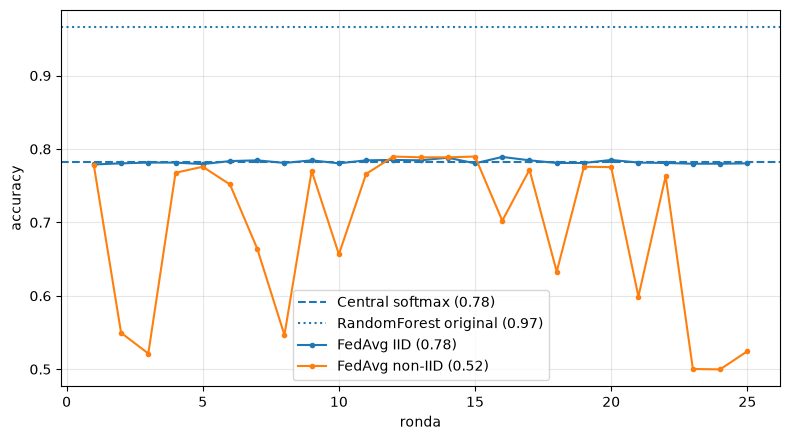

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4.5))
plt.axhline(acc_central, ls="--", label=f"Central softmax ({acc_central:.2f})")
plt.axhline(acc_rf, ls=":", label=f"RandomForest original ({acc_rf:.2f})")
plt.plot(range(1,len(hist_iid)+1),  hist_iid,  "-o", ms=3, label=f"FedAvg IID ({hist_iid[-1]:.2f})")
plt.plot(range(1,len(hist_niid)+1), hist_niid, "-o", ms=3, label=f"FedAvg non-IID ({hist_niid[-1]:.2f})")
plt.xlabel("ronda")
plt.ylabel("accuracy")
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()


## 6. (Opcional) Privacidad diferencial

Agrega ruido a los pesos agregados y mide cómo cae la accuracy.

sigma= 0.0: accuracy final=0.788
sigma=0.05: accuracy final=0.781
sigma= 0.1: accuracy final=0.778
sigma= 0.2: accuracy final=0.744


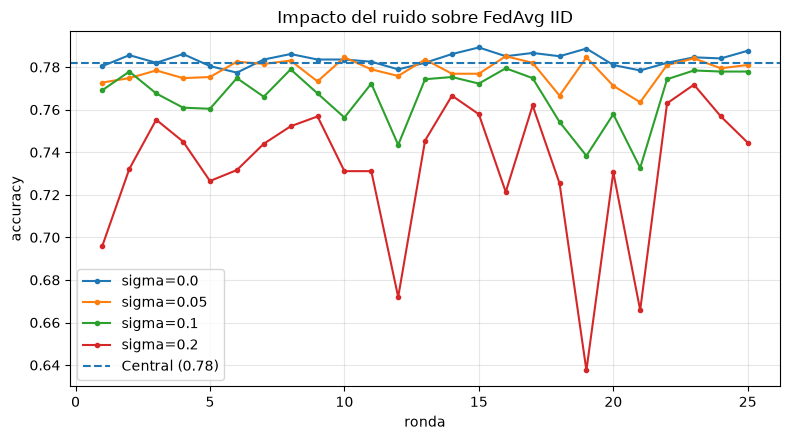

In [7]:
def federado_con_ruido(clientes, sigma, R=25, frac=0.4, epocas=25, lr=0.2, seed=1):
    """Simulación didáctica: ruido gaussiano luego de FedAvg.
    No es DP formal porque no incluye clipping ni privacy accounting.
    """
    rng_dp = np.random.RandomState(seed)
    W, b = init_modelo()
    K = len(clientes)
    m = max(1, int(frac * K))
    hist = []
    for _ in range(R):
        sel = rng_dp.choice(K, m, replace=False)
        ups = [entrenar_local(W, b, *clientes[i], epocas, lr) for i in sel]
        W, b = fedavg(ups)
        if sigma > 0:
            W += rng_dp.normal(0, sigma, size=W.shape)
            b += rng_dp.normal(0, sigma, size=b.shape)
        hist.append(accuracy(W, b))
    return W, b, hist

sigmas = [0.0, 0.05, 0.1, 0.2]
resultados_dp = {}
for sigma in sigmas:
    _, _, hist_dp = federado_con_ruido(clientes_iid, sigma=sigma)
    resultados_dp[sigma] = hist_dp
    print(f"sigma={sigma:>4}: accuracy final={hist_dp[-1]:.3f}")

plt.figure(figsize=(8,4.5))
for sigma, hist_dp in resultados_dp.items():
    plt.plot(range(1,len(hist_dp)+1), hist_dp, marker="o", ms=3, label=f"sigma={sigma}")
plt.axhline(acc_central, ls="--", label=f"Central ({acc_central:.2f})")
plt.xlabel("ronda")
plt.ylabel("accuracy")
plt.title("Impacto del ruido sobre FedAvg IID")
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()


### Reflexión

Sobre el mismo dataset de **predicción de stroke**, el clasificador softmax centralizado obtuvo una accuracy de **0.782** y FedAvg con partición IID **0.780**, por lo que el costo de federar fue de aproximadamente **0.2 puntos porcentuales**. Con la partición non-IID la accuracy final cayó a **0.525** y la curva fue mucho más inestable, porque en esta simulación varios clientes observan casi exclusivamente una clase y cada ronda usa sólo una fracción de ellos. El `RandomForestClassifier` original de `common` queda cargado como referencia del proyecto y tiene una accuracy registrada de **0.966**, pero no se federa directamente porque los árboles no tienen un vector de pesos compatible con FedAvg. Al agregar ruido, la accuracy IID bajó de alrededor de **0.788** sin ruido a **0.744** con `sigma=0.2`; una implementación real de privacidad diferencial debería sumar clipping y privacy accounting. En un escenario de centros de salud independientes, federar sería orgánico para evitar centralizar historias clínicas; dentro de una única organización, probablemente sería una complejidad adicional innecesaria.
